# 信頼区間（Quantile Regression）の効果検証

`src/modeling/train_quantile.py` で学習した 3 分位点モデル（α=0.05 / 0.50 / 0.95）と、
`src/visualization/prediction.py` の `predict_with_interval()` を実データで適用し、
**カバレッジ率・区間幅・価格帯別の挙動**を可視化する検証ノート。

解釈ガイド: [../docs/explainability/confidence_interval_guide.md](../docs/explainability/confidence_interval_guide.md)

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib_fontja
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# 日本語フォント適用（seaborn の style 設定後に明示的に再適用する）
sns.set_style("whitegrid")
matplotlib_fontja.japanize()
plt.rcParams["font.family"] = "IPAexGothic"

# プロジェクトルートを sys.path に追加
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling.train import prepare_dataset  # noqa: E402
from src.utils.config import load_model_params  # noqa: E402
from src.visualization.prediction import (  # noqa: E402
    LOWER_COL,
    MEDIAN_COL,
    UPPER_COL,
    load_quantile_models,
    predict_with_interval,
)

pd.set_option("display.max_columns", None)

# 動作確認: 適用されている font.family を表示
print(f"font.family = {plt.rcParams['font.family']}")

font.family = ['IPAexGothic']


## 1. モデル読み込み・予測

`load_quantile_models()` で 3 つの分位点モデルをロード、テストセットに対して `predict_with_interval()` を適用する。

In [11]:
# モデルロード
models = load_quantile_models(PROJECT_ROOT / "models")
print(f"ロードした分位点モデル: α = {sorted(models.keys())}")

# 学習時と同じ分割設定でテストセットを再現
x, y = prepare_dataset()
split = load_model_params()["split"]
x_train, x_test, y_train, y_test = train_test_split(x, y, **split)
print(f"x_test shape: {x_test.shape}")

# 区間予測（円スケール）
intervals = predict_with_interval(models, x_test, return_yen=True)
intervals.head()

ロードした分位点モデル: α = [0.05, 0.5, 0.95]
x_test shape: (9915, 33)


,lower,median,upper
37793,4.459752e+07,5.379714e+07,6.069829e+07
32707,5.323417e+07,7.170035e+07,8.441784e+07
14320,8.777516e+07,1.852105e+08,2.378216e+08
30352,3.442486e+07,4.700005e+07,6.348549e+07
7787,3.536029e+07,4.255806e+07,5.035719e+07


## 2. カバレッジ率と区間幅（全体）

- **カバレッジ率**: 実価格が `[lower, upper]` に入った割合。名目 90% に近いほど良いキャリブレーション。
- **区間幅**: `upper - lower`。狭くて当たるのが理想、広すぎると実用性が落ちる。

In [12]:
# 実価格と並べた結果テーブル
actual_yen = np.exp(y_test).reset_index(drop=True)
result = intervals.reset_index(drop=True).assign(actual=actual_yen)
result["width"] = result[UPPER_COL] - result[LOWER_COL]
result["inside"] = (result["actual"] >= result[LOWER_COL]) & (
    result["actual"] <= result[UPPER_COL]
)
result["abs_error"] = (result["actual"] - result[MEDIAN_COL]).abs()
result["ape"] = result["abs_error"] / result["actual"] * 100

# サマリ
nominal_coverage = 0.90  # α = 0.05 〜 0.95
coverage_rate = result["inside"].mean()

print("==== 全体サマリ ====")
print(f"サンプル数            : {len(result):,}")
print(f"名目カバレッジ        : {nominal_coverage * 100:.0f}%")
print(f"実カバレッジ          : {coverage_rate * 100:.2f}%")
print(f"差分                  : {(coverage_rate - nominal_coverage) * 100:+.2f}pp")
print(f"区間幅 中央値         : {result['width'].median():,.0f} 円")
print(f"区間幅 平均           : {result['width'].mean():,.0f} 円")
print(
    f"区間幅 / 実価格 中央値: "
    f"{(result['width'] / result['actual']).median() * 100:.1f}%"
)

==== 全体サマリ ====
サンプル数            : 9,915
名目カバレッジ        : 90%
実カバレッジ          : 78.94%
差分                  : -11.06pp
区間幅 中央値         : 20,073,633 円
区間幅 平均           : 34,026,403 円
区間幅 / 実価格 中央値: 46.2%


## 3. 区間幅の分布

区間幅を絶対値（円）と相対値（実価格に対する割合）の両面で確認する。
中央値と平均が大きく乖離していれば、**高額物件で区間が広がっている**サイン。

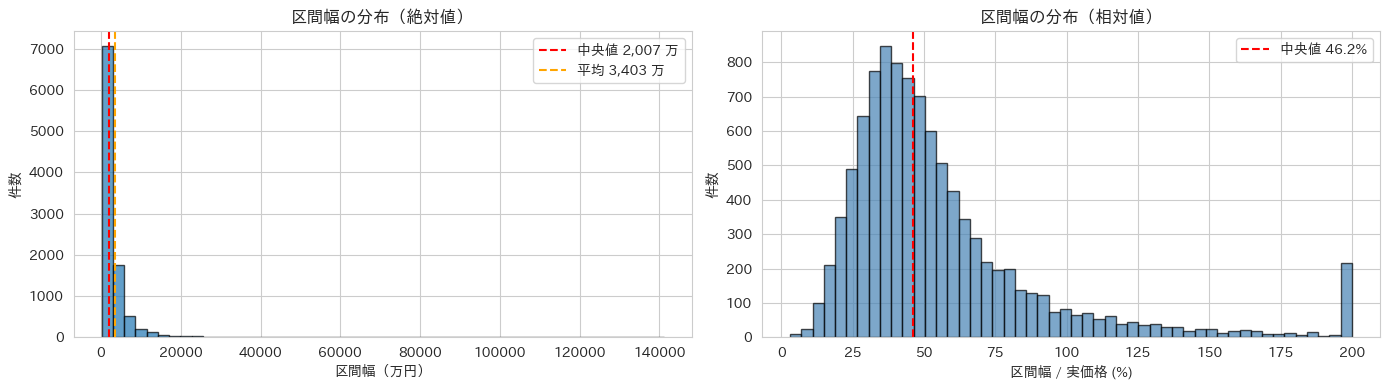

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (左) 区間幅の絶対値（万円単位）
width_man = result["width"] / 10_000
axes[0].hist(width_man, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(
    width_man.median(),
    color="red",
    linestyle="--",
    label=f"中央値 {width_man.median():,.0f} 万",
)
axes[0].axvline(
    width_man.mean(),
    color="orange",
    linestyle="--",
    label=f"平均 {width_man.mean():,.0f} 万",
)
axes[0].set_xlabel("区間幅（万円）")
axes[0].set_ylabel("件数")
axes[0].set_title("区間幅の分布（絶対値）")
axes[0].legend()

# (右) 区間幅の相対値（実価格に対する％）
rel_width = result["width"] / result["actual"] * 100
axes[1].hist(
    rel_width.clip(upper=200), bins=50, edgecolor="black", alpha=0.7, color="steelblue"
)
axes[1].axvline(
    rel_width.median(),
    color="red",
    linestyle="--",
    label=f"中央値 {rel_width.median():.1f}%",
)
axes[1].set_xlabel("区間幅 / 実価格 (%)")
axes[1].set_ylabel("件数")
axes[1].set_title("区間幅の分布（相対値）")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 予測区間 vs 実価格（散布図）

横軸に実価格、縦軸に予測中央値をプロット。エラーバーで区間を示す。
**45 度線上に並んでいれば中央値の精度が高い**。区間内に実価格があれば緑、外なら赤で着色。

⚠ Quantile crossing 検出: median < lower が 7 件, upper < median が 12 件（errorbar 用に 0 でクリップ）


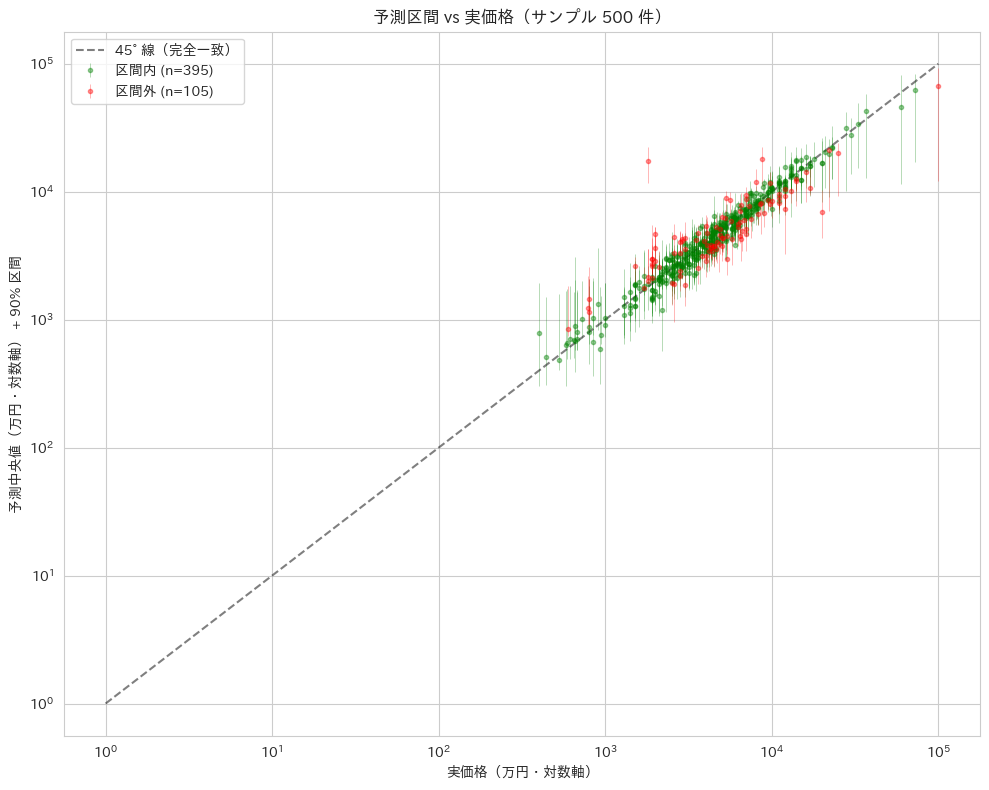

In [15]:
# 描画コストを抑えるため最大 500 件にサンプリング
n_plot = min(500, len(result))
plot_df = result.sample(n=n_plot, random_state=42).sort_values("actual")

# Quantile Crossing（lower > median や upper < median）の件数を確認
n_cross_lower = (plot_df[MEDIAN_COL] < plot_df[LOWER_COL]).sum()
n_cross_upper = (plot_df[UPPER_COL] < plot_df[MEDIAN_COL]).sum()
if n_cross_lower + n_cross_upper > 0:
    print(
        f"⚠ Quantile crossing 検出: median < lower が {n_cross_lower} 件, "
        f"upper < median が {n_cross_upper} 件（errorbar 用に 0 でクリップ）"
    )

fig, ax = plt.subplots(figsize=(10, 8))

# 区間内・区間外で色分け
inside_df = plot_df[plot_df["inside"]]
outside_df = plot_df[~plot_df["inside"]]

for sub, color, label in [
    (inside_df, "green", "区間内"),
    (outside_df, "red", "区間外"),
]:
    # クロスが起きたサンプルでエラーバーが負にならないよう 0 でクリップ
    yerr_lower = ((sub[MEDIAN_COL] - sub[LOWER_COL]) / 10_000).clip(lower=0)
    yerr_upper = ((sub[UPPER_COL] - sub[MEDIAN_COL]) / 10_000).clip(lower=0)
    ax.errorbar(
        sub["actual"] / 10_000,
        sub[MEDIAN_COL] / 10_000,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        markersize=3,
        alpha=0.4,
        color=color,
        ecolor=color,
        elinewidth=0.5,
        label=f"{label} (n={len(sub)})",
    )

# 45 度線
lim = max(plot_df["actual"].max(), plot_df[UPPER_COL].max()) / 10_000
ax.plot([1, lim], [1, lim], "k--", alpha=0.5, label="45° 線（完全一致）")

ax.set_xlabel("実価格（万円・対数軸）")
ax.set_ylabel("予測中央値（万円・対数軸） + 90% 区間")
ax.set_title(f"予測区間 vs 実価格（サンプル {n_plot} 件）")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 5. 価格帯別のカバレッジと区間幅

**全体カバレッジが目標を下回るとき、特定の価格帯で大きく外れていることが多い**。
低額帯・高額帯・中央帯で挙動が違うか確認する。

In [17]:
# 価格帯ビン（既存の actual_price_band と同じ区切り）
bins = [0, 20_000_000, 50_000_000, 100_000_000, 300_000_000, np.inf]
labels = ["〜2000万", "2000万〜5000万", "5000万〜1億", "1億〜3億", "3億〜"]
result["band"] = pd.cut(result["actual"], bins=bins, labels=labels)

band_summary = (
    result.groupby("band", observed=True)
    .agg(
        n=("actual", "size"),
        coverage=("inside", "mean"),
        width_median=("width", "median"),
        ape_median=("ape", "median"),
    )
    .reset_index()
)
band_summary["coverage_%"] = (band_summary["coverage"] * 100).round(2)
band_summary["width_median_万円"] = (band_summary["width_median"] / 10_000).round(0)
band_summary["ape_median_%"] = band_summary["ape_median"].round(2)
display(
    band_summary[["band", "n", "coverage_%", "width_median_万円", "ape_median_%"]]
)

,band,n,coverage_%,width_median_万円,ape_median_%
0,〜2000万,1304,76.76,1360.0,17.88
1,2000万〜5000万,4104,80.46,1572.0,10.29
2,5000万〜1億,2898,78.23,2597.0,8.85
3,1億〜3億,1491,78.34,6468.0,10.09
4,3億〜,118,75.42,33161.0,17.11


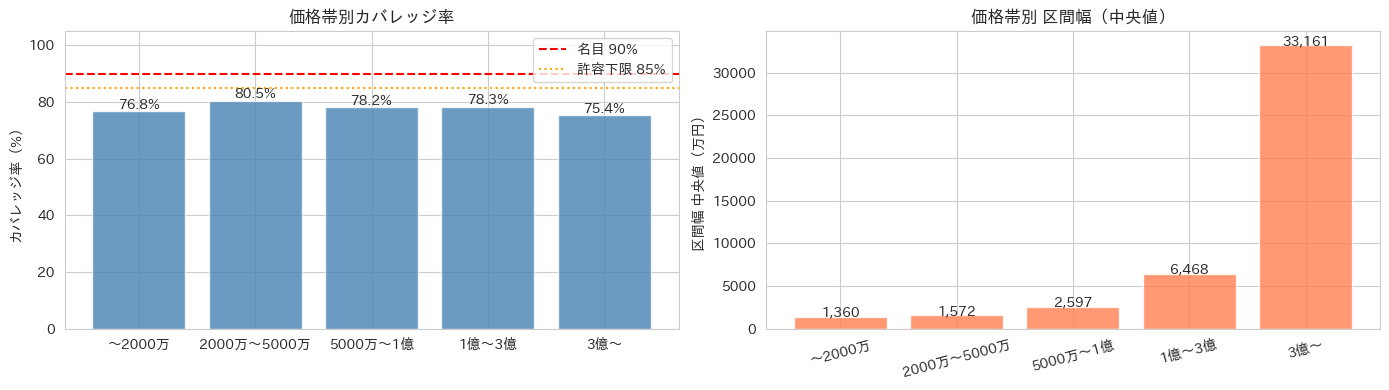

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (左) 価格帯別カバレッジ率
ax = axes[0]
bars = ax.bar(
    band_summary["band"].astype(str),
    band_summary["coverage_%"],
    color="steelblue",
    alpha=0.8,
)
ax.axhline(90, color="red", linestyle="--", label="名目 90%")
ax.axhline(85, color="orange", linestyle=":", label="許容下限 85%")
for bar, value in zip(bars, band_summary["coverage_%"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
    )
ax.set_ylabel("カバレッジ率（%）")
ax.set_title("価格帯別カバレッジ率")
ax.set_ylim(0, 105)
ax.legend()

# (右) 価格帯別の区間幅中央値
ax = axes[1]
bars = ax.bar(
    band_summary["band"].astype(str),
    band_summary["width_median_万円"],
    color="coral",
    alpha=0.8,
)
for bar, value in zip(bars, band_summary["width_median_万円"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 50,
        f"{value:,.0f}",
        ha="center",
    )
ax.set_ylabel("区間幅 中央値（万円）")
ax.set_title("価格帯別 区間幅（中央値）")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. サンプル物件の区間可視化

個別の予測がどう見えるかを 10 件可視化。実価格（◆）が区間（横棒）に収まっているかを目視確認。

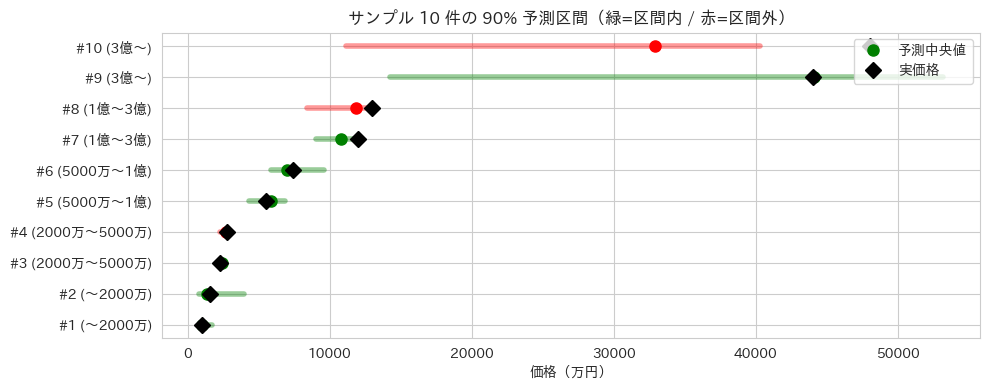

,lower,median,upper,actual,width,ape,inside,band
0,985万,1028万,1707万,1000万,722万,2.8%,True,〜2000万
1,798万,1348万,3948万,1600万,3151万,15.8%,True,〜2000万
2,2101万,2398万,2620万,2300万,519万,4.3%,True,2000万〜5000万
3,2308万,2672万,2775万,2800万,466万,4.6%,False,2000万〜5000万
4,4327万,5856万,6884万,5500万,2558万,6.5%,True,5000万〜1億
5,5839万,6976万,9579万,7400万,3740万,5.7%,True,5000万〜1億
6,9011万,10797万,12282万,12000万,3271万,10.0%,True,1億〜3億
7,8406万,11856万,12888万,13000万,4481万,8.8%,False,1億〜3億
8,14223万,44081万,53157万,44000万,38934万,0.2%,True,3億〜
9,11111万,32899万,40277万,48000万,29166万,31.5%,False,3億〜


In [20]:
# 価格帯ごとに分散して 10 件サンプリング
# （pandas 3.0 では groupby.apply が grouping 列「band」を落とすため、ループで明示的に集める）
sample_parts = [
    g.sample(min(2, len(g)), random_state=42)
    for _, g in result.groupby("band", observed=True)
]
sample = (
    pd.concat(sample_parts)
    .head(10)
    .sort_values("actual")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(sample) * 0.4)))

y_pos = np.arange(len(sample))
for i, row in sample.iterrows():
    color = "green" if row["inside"] else "red"
    # 区間バー（Quantile crossing で lower > upper になる場合に備え min/max で順序保証）
    lo = min(row[LOWER_COL], row[UPPER_COL]) / 10_000
    hi = max(row[LOWER_COL], row[UPPER_COL]) / 10_000
    ax.plot([lo, hi], [i, i], color=color, linewidth=4, alpha=0.4)
    # 予測中央値
    ax.plot(
        row[MEDIAN_COL] / 10_000,
        i,
        "o",
        color=color,
        markersize=8,
        label="予測中央値" if i == 0 else "",
    )
    # 実価格
    ax.plot(
        row["actual"] / 10_000,
        i,
        "D",
        color="black",
        markersize=8,
        label="実価格" if i == 0 else "",
    )

ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i + 1} ({row['band']})" for i, row in sample.iterrows()])
ax.set_xlabel("価格（万円）")
ax.set_title("サンプル 10 件の 90% 予測区間（緑=区間内 / 赤=区間外）")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 数値表も併記
display_cols = [LOWER_COL, MEDIAN_COL, UPPER_COL, "actual", "width", "ape", "inside", "band"]
sample_display = sample[display_cols].copy()
for col in [LOWER_COL, MEDIAN_COL, UPPER_COL, "actual", "width"]:
    sample_display[col] = (
        (sample_display[col] / 10_000).round(0).astype(int).astype(str) + "万"
    )
sample_display["ape"] = sample_display["ape"].round(1).astype(str) + "%"
display(sample_display)

## まとめと次のアクション

- 全体カバレッジ・区間幅の数値は学習ログ（`logs/train_quantile.log`）の `__main__` 行とも突合できる
- 価格帯別の挙動から「どの帯が過信 / 過小評価か」が見える → Phase 5 で評価指標として恒久化
- 解釈の詳細は [信頼区間ガイド](../docs/explainability/confidence_interval_guide.md) を参照